# 02 · No-Persona Similarity Analysis

Compares `NP-Think` and `NP-NoThink` no-persona conditions against the persona-conditioned pool using cosine similarity of Sentence-BERT embeddings.

In [1]:
import sys, json
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity as _cs

from src.config import FIGURES, OUTPUTS, FONT_SCALE, NP_THINK_PATH, NP_NOTHINK_PATH
from src.data_loading import load_annotations, parse_demographics, create_profiles

sns.set_theme(style="whitegrid", font_scale=FONT_SCALE)
plt.rcParams["figure.dpi"] = 150

FIGURES.mkdir(exist_ok=True)
OUTPUTS.mkdir(exist_ok=True)

df = load_annotations()
df = parse_demographics(df)
df = create_profiles(df)
print(f"Persona records: {len(df):,} | Images: {df['image_id'].nunique():,}")

Persona records: 59,999 | Images: 50


## 1 · Load persona-pool embeddings

In [2]:
cap_embs  = np.load(OUTPUTS / "caption_embeddings.npy")
just_embs = np.load(OUTPUTS / "justification_embeddings.npy")
cap_ids   = pd.read_csv(OUTPUTS / "caption_embeddings_ids.csv")
# Build annotation_id → row index map
_ann2idx = {aid: i for i, aid in enumerate(cap_ids["annotation_id"].tolist())}
print(f"Caption embeddings:       {cap_embs.shape}")
print(f"Justification embeddings: {just_embs.shape}")

Caption embeddings:       (59999, 384)
Justification embeddings: (59999, 384)


## 2 · Load no-persona data and encode

In [3]:
from sentence_transformers import SentenceTransformer as _ST

# NP_THINK_PATH / NP_NOTHINK_PATH come from src.config (model-aware).
np_think_df   = pd.DataFrame([json.loads(l) for l in NP_THINK_PATH.open()])
np_nothink_df = pd.DataFrame([json.loads(l) for l in NP_NOTHINK_PATH.open()])
print(f"NP-Think: {len(np_think_df):,}  |  NP-NoThink: {len(np_nothink_df):,}")

_model = _ST("sentence-transformers/all-MiniLM-L6-v2")

# Think condition ─────────────────────────────────────────────────────────────
NP_THINK_CAP_CACHE  = OUTPUTS / "np_caption_embeddings.npy"
NP_THINK_JUST_CACHE = OUTPUTS / "np_just_embeddings.npy"
if NP_THINK_CAP_CACHE.exists():
    np_think_cap_embs  = np.load(NP_THINK_CAP_CACHE)
    np_think_just_embs = np.load(NP_THINK_JUST_CACHE)
    print(f"Loaded NP-Think cache: {np_think_cap_embs.shape}")
else:
    np_think_cap_embs  = _model.encode(np_think_df["caption"].tolist(),
                                        normalize_embeddings=True, show_progress_bar=True)
    np_think_just_embs = _model.encode(np_think_df["justification"].tolist(),
                                        normalize_embeddings=True, show_progress_bar=True)
    np.save(NP_THINK_CAP_CACHE,  np_think_cap_embs)
    np.save(NP_THINK_JUST_CACHE, np_think_just_embs)

# NoThink condition ───────────────────────────────────────────────────────────
NP_NOTHINK_CAP_CACHE  = OUTPUTS / "np_nothink_caption_embeddings.npy"
NP_NOTHINK_JUST_CACHE = OUTPUTS / "np_nothink_just_embeddings.npy"
if NP_NOTHINK_CAP_CACHE.exists():
    np_nothink_cap_embs  = np.load(NP_NOTHINK_CAP_CACHE)
    np_nothink_just_embs = np.load(NP_NOTHINK_JUST_CACHE)
    print(f"Loaded NP-NoThink cache: {np_nothink_cap_embs.shape}")
else:
    np_nothink_cap_embs  = _model.encode(np_nothink_df["caption"].tolist(),
                                          normalize_embeddings=True, show_progress_bar=True)
    np_nothink_just_embs = _model.encode(np_nothink_df["justification"].tolist(),
                                          normalize_embeddings=True, show_progress_bar=True)
    np.save(NP_NOTHINK_CAP_CACHE,  np_nothink_cap_embs)
    np.save(NP_NOTHINK_JUST_CACHE, np_nothink_just_embs)

NP-Think: 250  |  NP-NoThink: 250


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loaded NP-Think cache: (250, 384)
Loaded NP-NoThink cache: (250, 384)


## 3 · Compute per-image similarity to persona pool

In [4]:
sim_lookup      = pd.read_csv(OUTPUTS / "per_image_cosine_similarity.csv").set_index("image_id")["mean_sim"].to_dict()
just_sim_lookup = pd.read_csv(OUTPUTS / "per_image_just_similarity.csv").set_index("image_id")["mean_just_sim"].to_dict()

df_r = df.reset_index(drop=True)

rows = []
for img_id, group in df_r.groupby("image_id"):
    grp_ann_ids  = group["annotation_id"].tolist()
    grp_cap_idx  = [_ann2idx[a] for a in grp_ann_ids if a in _ann2idx]
    if not grp_cap_idx:
        continue
    cap_pool  = cap_embs[grp_cap_idx]
    just_pool = just_embs[grp_cap_idx]

    # find row in no-persona df
    r_think   = np_think_df[np_think_df["image_id"] == img_id]
    r_nothink = np_nothink_df[np_nothink_df["image_id"] == img_id]

    if not r_think.empty:
        i_t = r_think.index[0]
        rows.append({
            "image_id":         img_id,
            "condition":        "NP-Think",
            "np_cap_sim_mean":  float(_cs(np_think_cap_embs[[i_t]],  cap_pool)[0].mean()),
            "np_just_sim_mean": float(_cs(np_think_just_embs[[i_t]], just_pool)[0].mean()),
            "persona_cap_sim":  sim_lookup.get(img_id, float("nan")),
            "persona_just_sim": just_sim_lookup.get(img_id, float("nan")),
        })

    if not r_nothink.empty:
        i_n = r_nothink.index[0]
        rows.append({
            "image_id":         img_id,
            "condition":        "NP-NoThink",
            "np_cap_sim_mean":  float(_cs(np_nothink_cap_embs[[i_n]],  cap_pool)[0].mean()),
            "np_just_sim_mean": float(_cs(np_nothink_just_embs[[i_n]], just_pool)[0].mean()),
            "persona_cap_sim":  sim_lookup.get(img_id, float("nan")),
            "persona_just_sim": just_sim_lookup.get(img_id, float("nan")),
        })

np_comp_df = pd.DataFrame(rows)
np_comp_df.to_csv(OUTPUTS / "no_persona_text_similarity.csv", index=False)
print(np_comp_df.groupby("condition")[["np_cap_sim_mean", "np_just_sim_mean",
                                        "persona_cap_sim", "persona_just_sim"]].mean().round(4))

            np_cap_sim_mean  np_just_sim_mean  persona_cap_sim  \
condition                                                        
NP-NoThink           0.8876            0.5611           0.9036   
NP-Think             0.8248            0.5524           0.9036   

            persona_just_sim  
condition                     
NP-NoThink            0.5959  
NP-Think              0.5959  


## 4 · Figure — no-persona vs. persona pool similarity

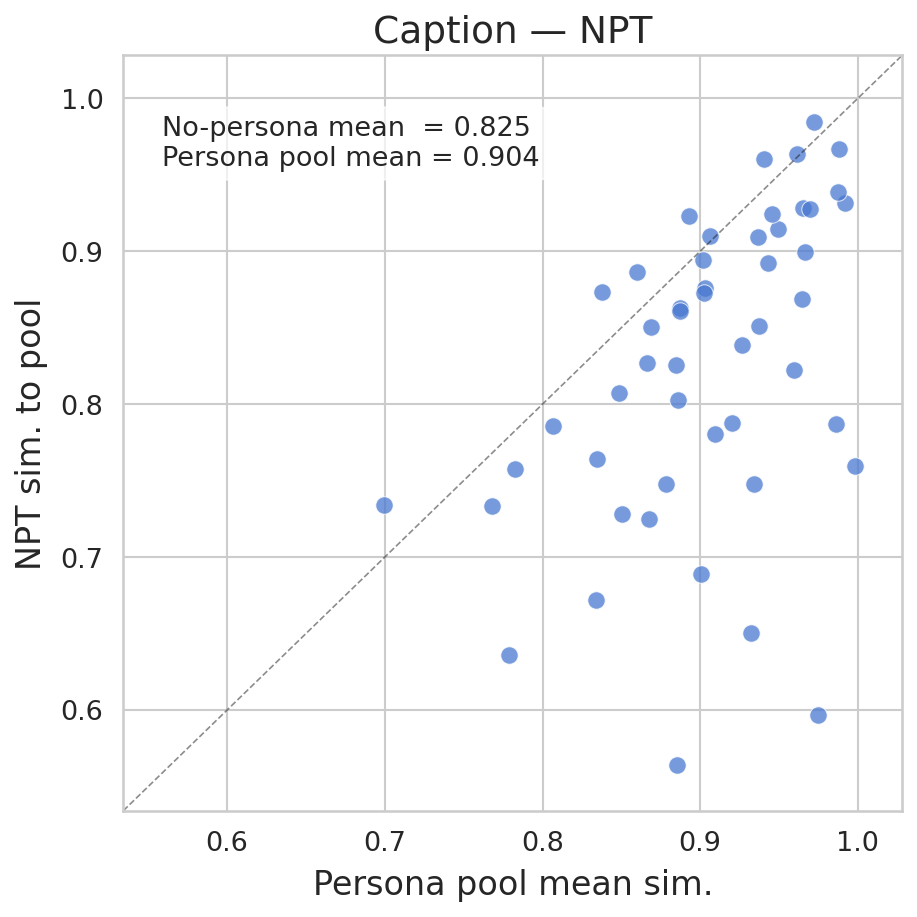

Saved fig_no_persona_caption_npt


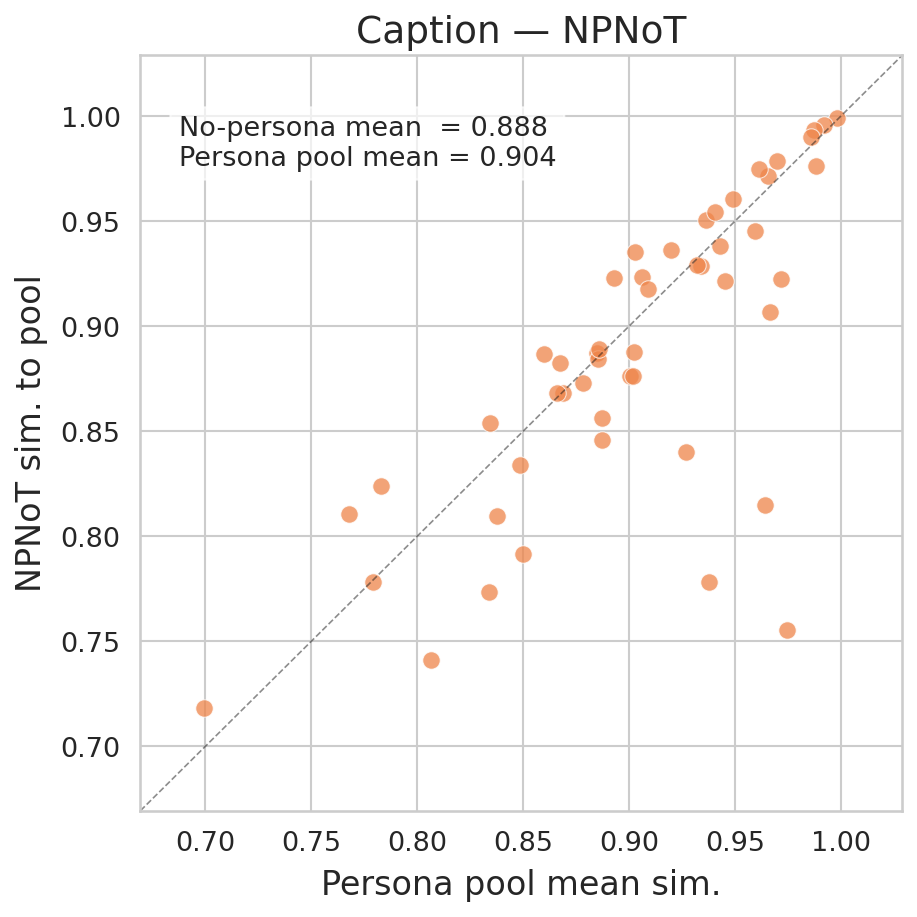

Saved fig_no_persona_caption_npnot


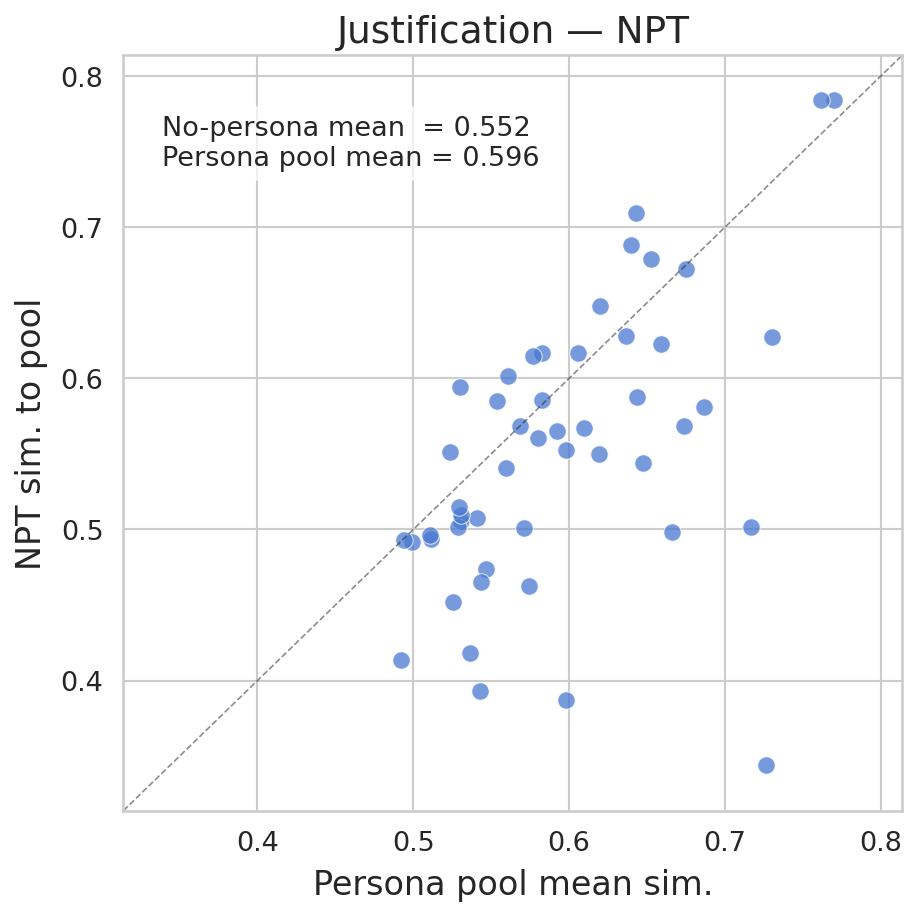

Saved fig_no_persona_just_npt


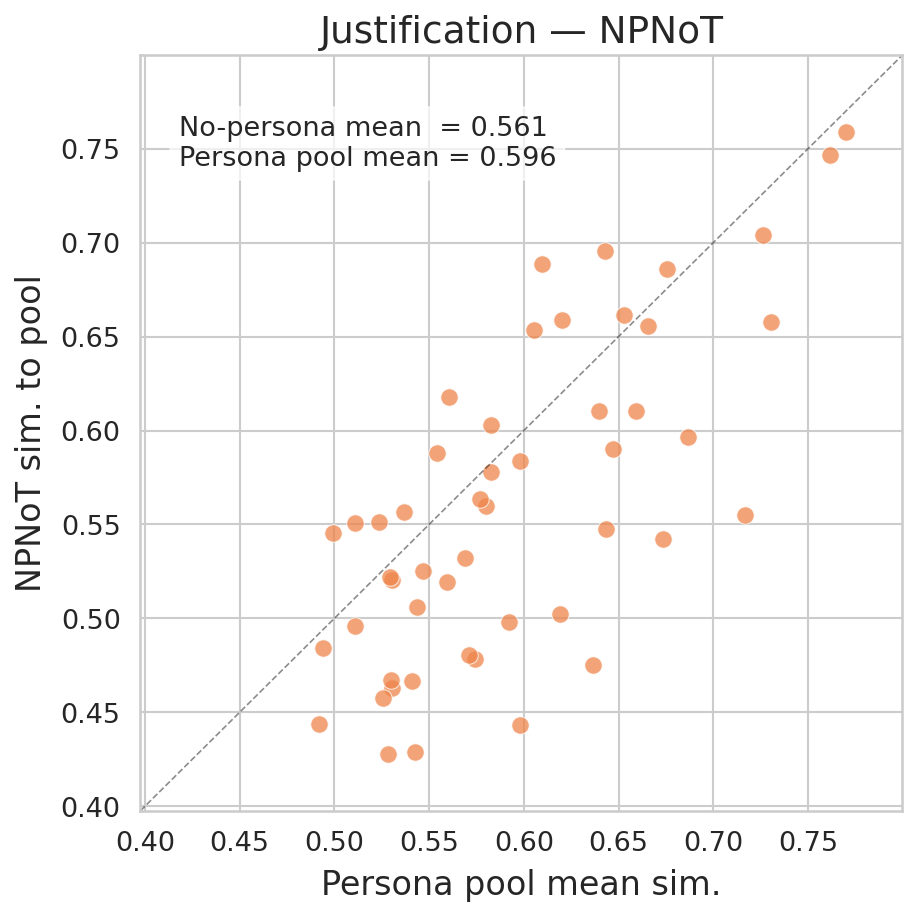

Saved fig_no_persona_just_npnot


In [5]:
sns.set_theme(style="whitegrid", font_scale=FONT_SCALE)
MUTED = sns.color_palette("muted")

conditions = ["NPT", "NPNoT"]
conditions_orig = {"NPT": "NP-Think", "NPNoT": "NP-NoThink"}
# (np_col, pers_col, display title, filename slug)
modalities = [
    ("np_cap_sim_mean",  "persona_cap_sim",  "Caption",       "caption"),
    ("np_just_sim_mean", "persona_just_sim", "Justification", "just"),
]

# Supervisor request: emit one standalone single-panel figure per
# (modality, condition) so each can be placed independently in the paper.
for np_col, pers_col, mod_title, mod_slug in modalities:
    for col_i, cond in enumerate(conditions):
        orig_cond = conditions_orig[cond]
        sub = np_comp_df[np_comp_df["condition"] == orig_cond]

        fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)
        ax.scatter(sub[pers_col], sub[np_col],
                   alpha=0.75, s=70, color=MUTED[col_i],
                   edgecolors="white", linewidths=0.5)
        lims = [
            min(sub[pers_col].min(), sub[np_col].min()) - 0.03,
            max(sub[pers_col].max(), sub[np_col].max()) + 0.03,
        ]
        ax.plot(lims, lims, "k--", linewidth=0.8, alpha=0.5)
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_xlabel("Persona pool mean sim.", labelpad=6, fontsize=16)
        ax.set_ylabel(f"{cond} sim. to pool", labelpad=6, fontsize=16)
        ax.set_title(f"{mod_title} — {cond}", fontsize=18)
        ax.tick_params(axis="both", labelsize=13)
        np_mean   = sub[np_col].mean()
        pers_mean = sub[pers_col].mean()
        ax.text(0.05, 0.92,
                f"No-persona mean  = {np_mean:.3f}\nPersona pool mean = {pers_mean:.3f}",
                transform=ax.transAxes, fontsize=13, va="top",
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

        fname = f"fig_no_persona_{mod_slug}_{cond.lower()}"
        fig.savefig(FIGURES / f"{fname}.pdf", bbox_inches="tight")
        fig.savefig(FIGURES / f"{fname}.png", bbox_inches="tight")
        plt.show()
        print(f"Saved {fname}")


## 5 · Full similarity matrix — NPT, NPNoT vs all personas


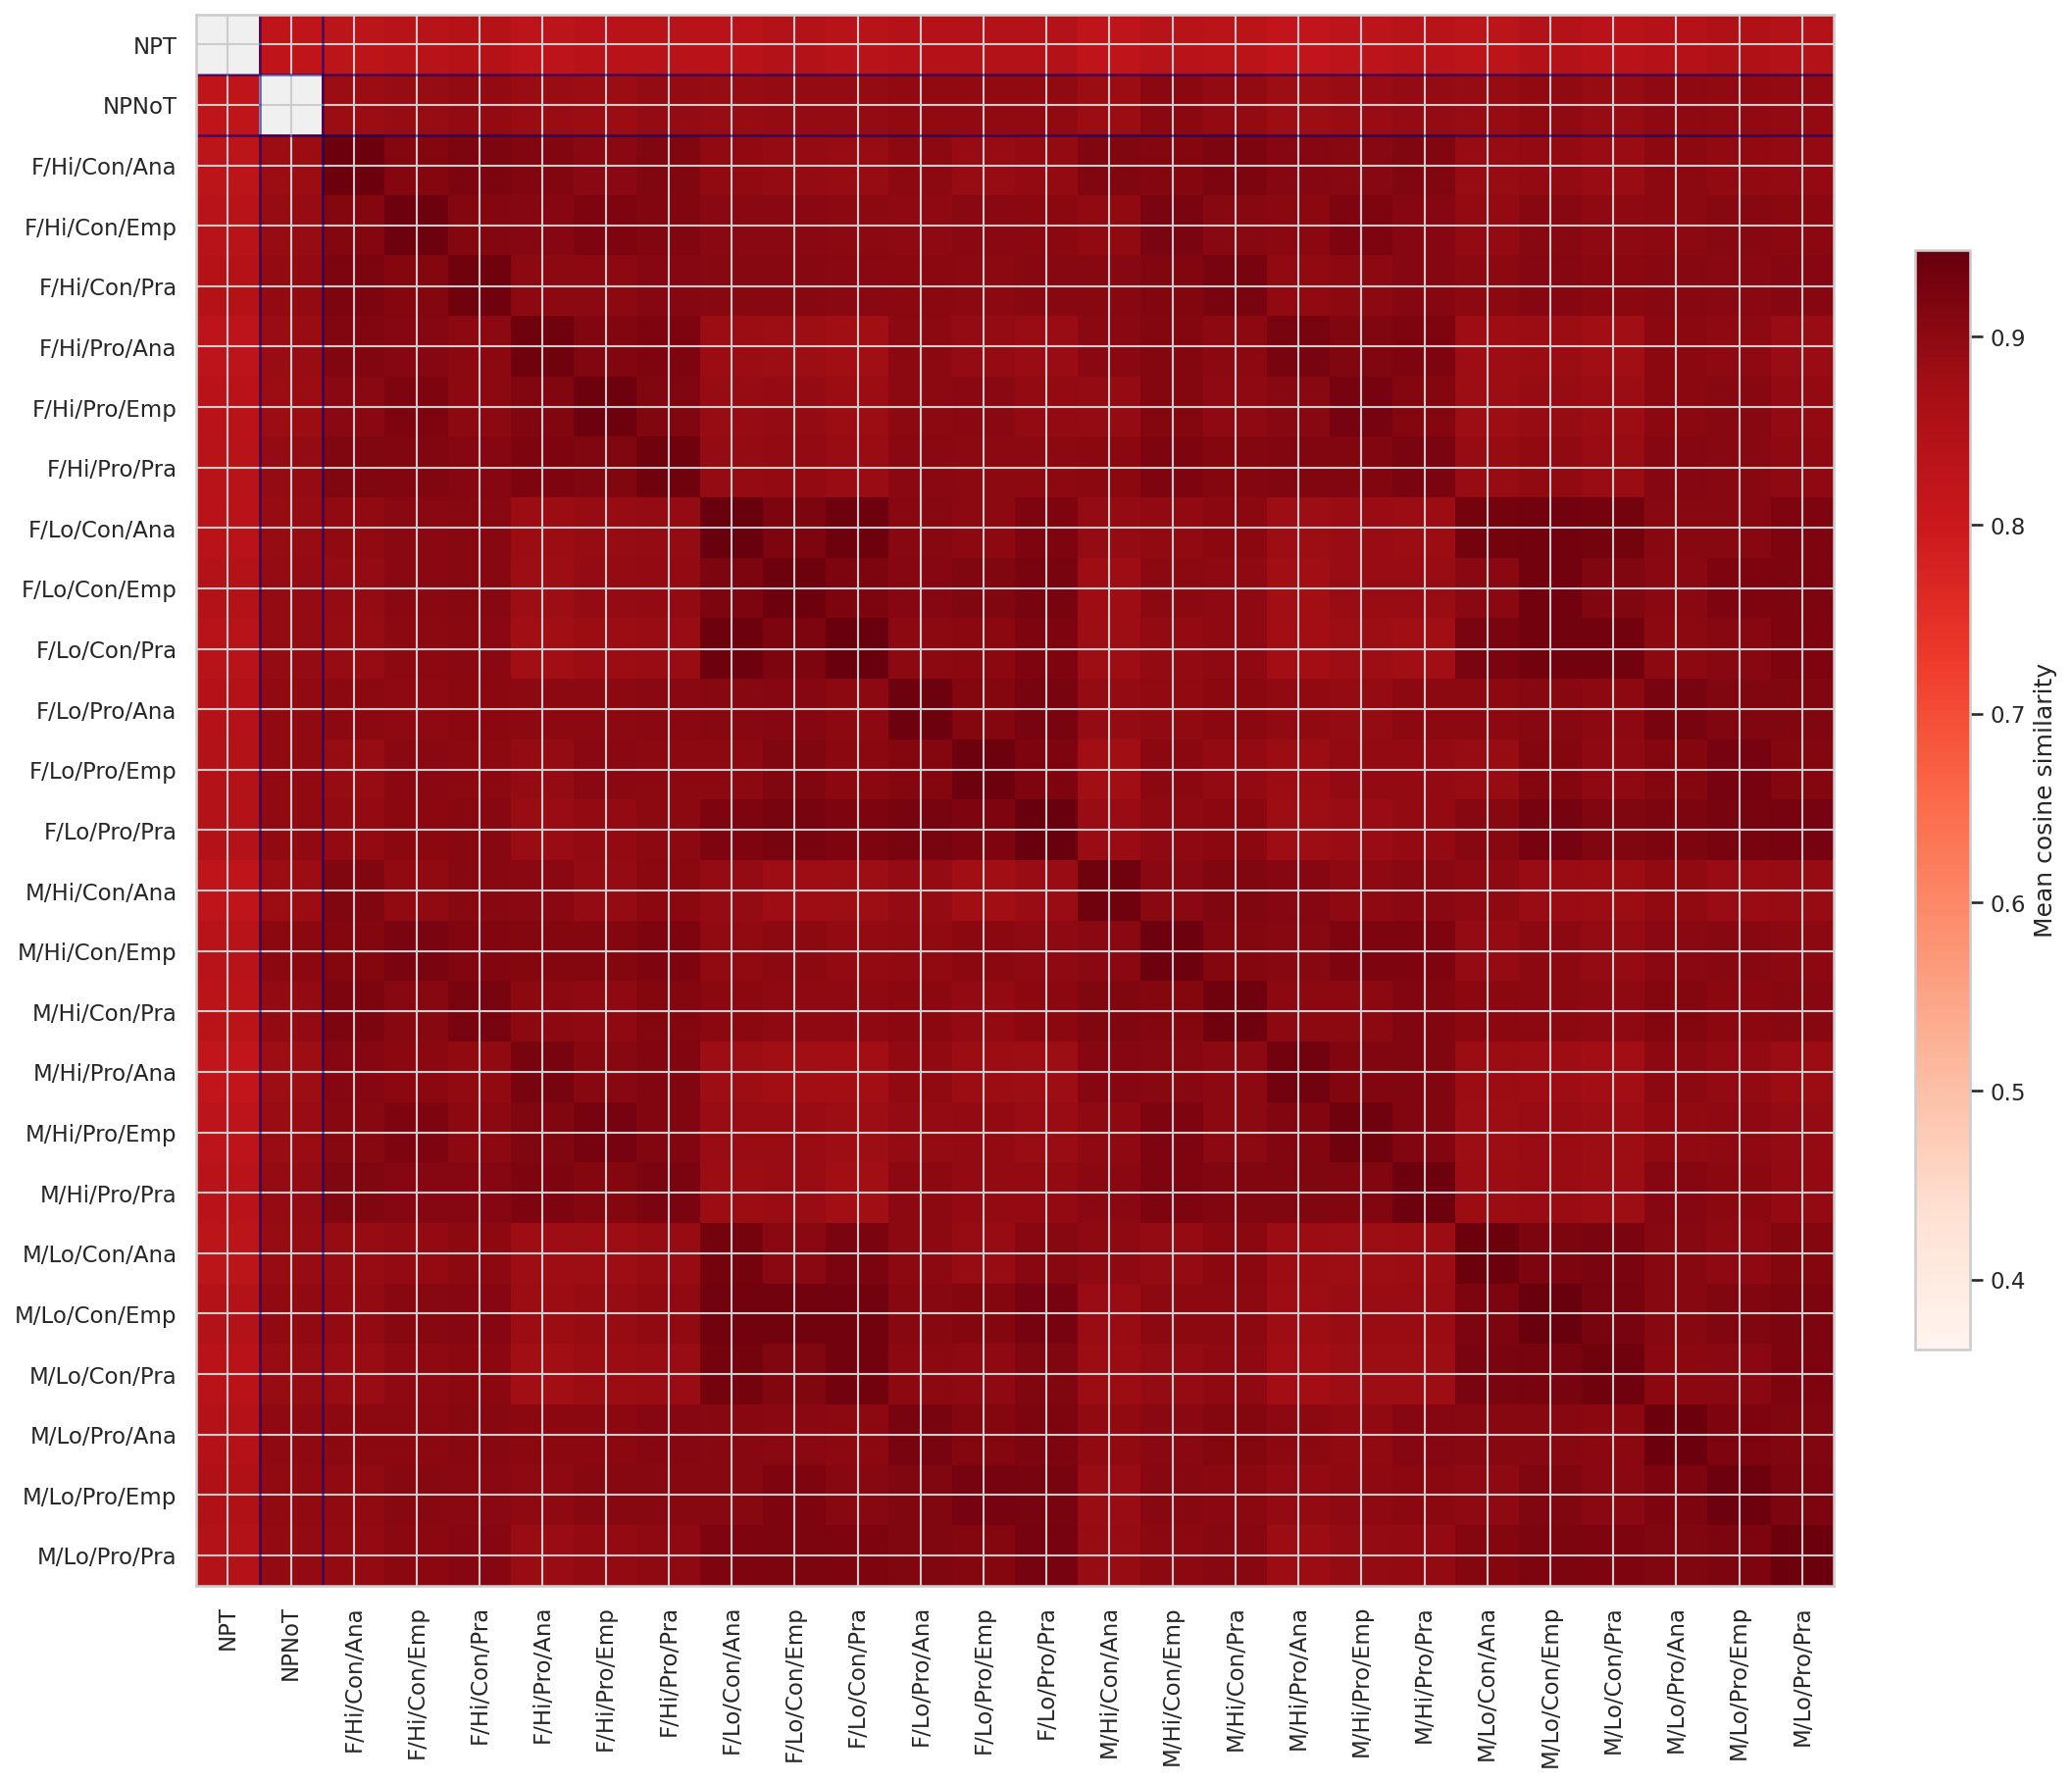

Saved fig_no_persona_full_sim_matrix_caption


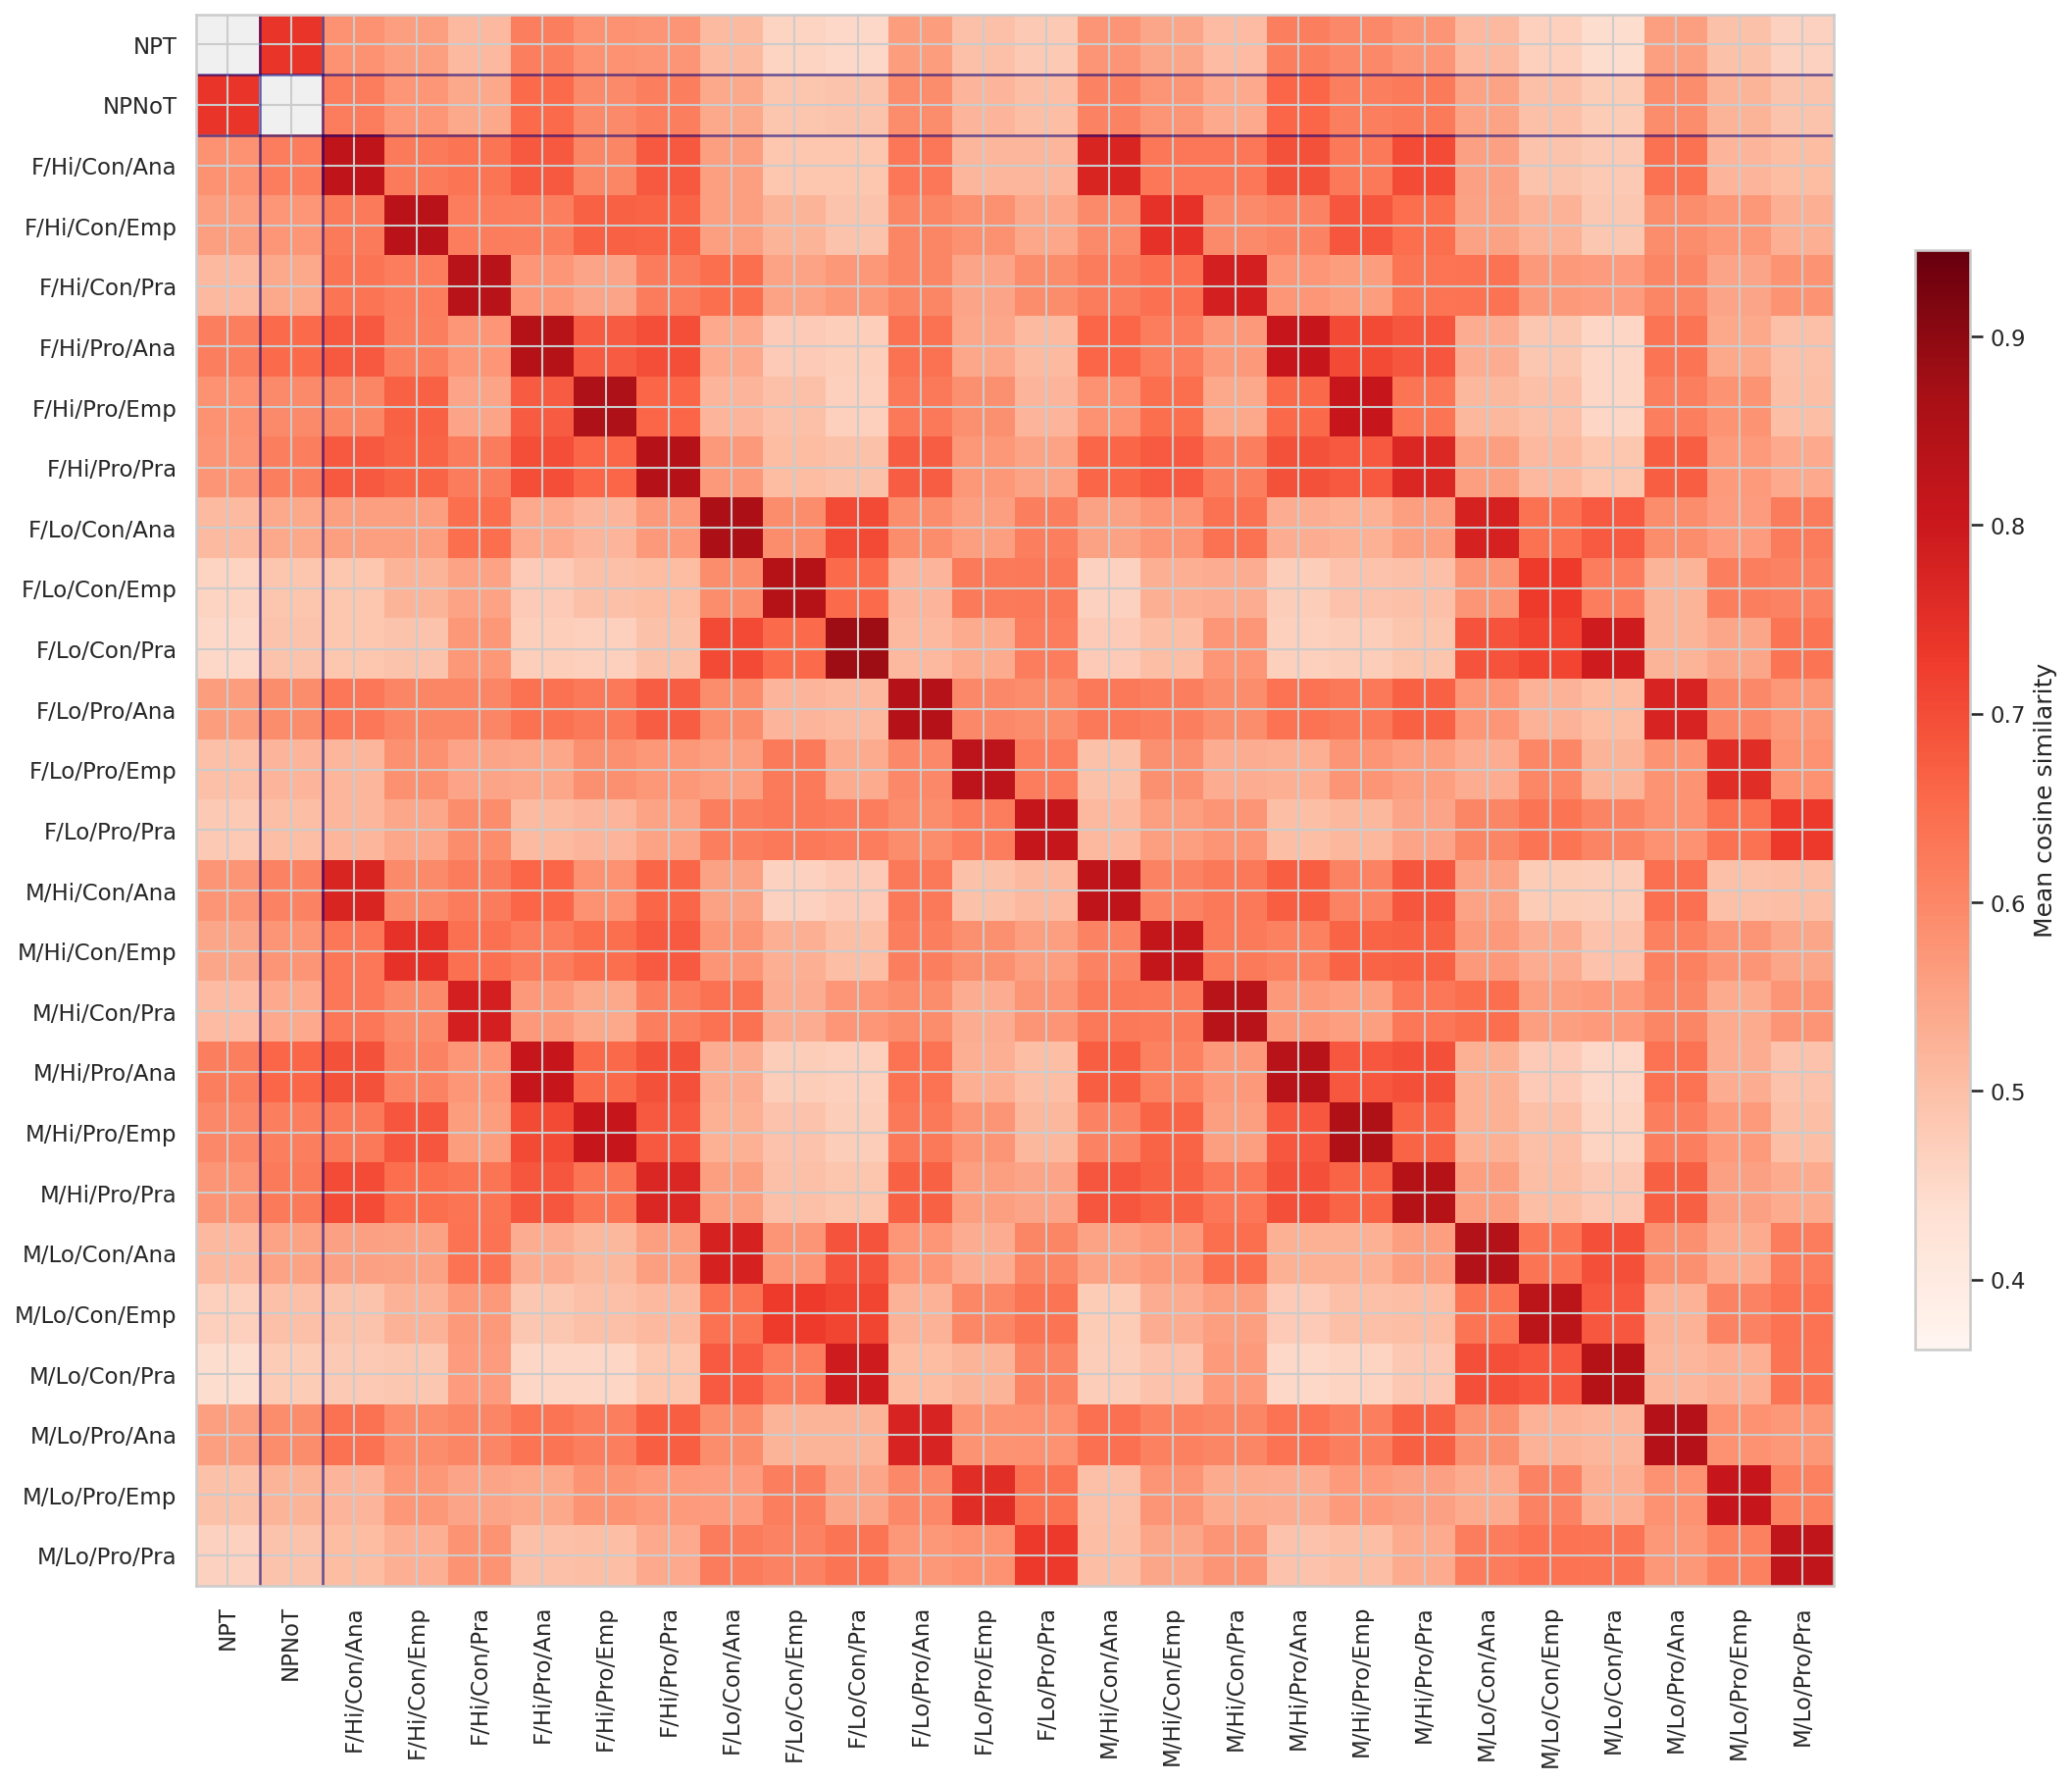

Saved fig_no_persona_full_sim_matrix_justification


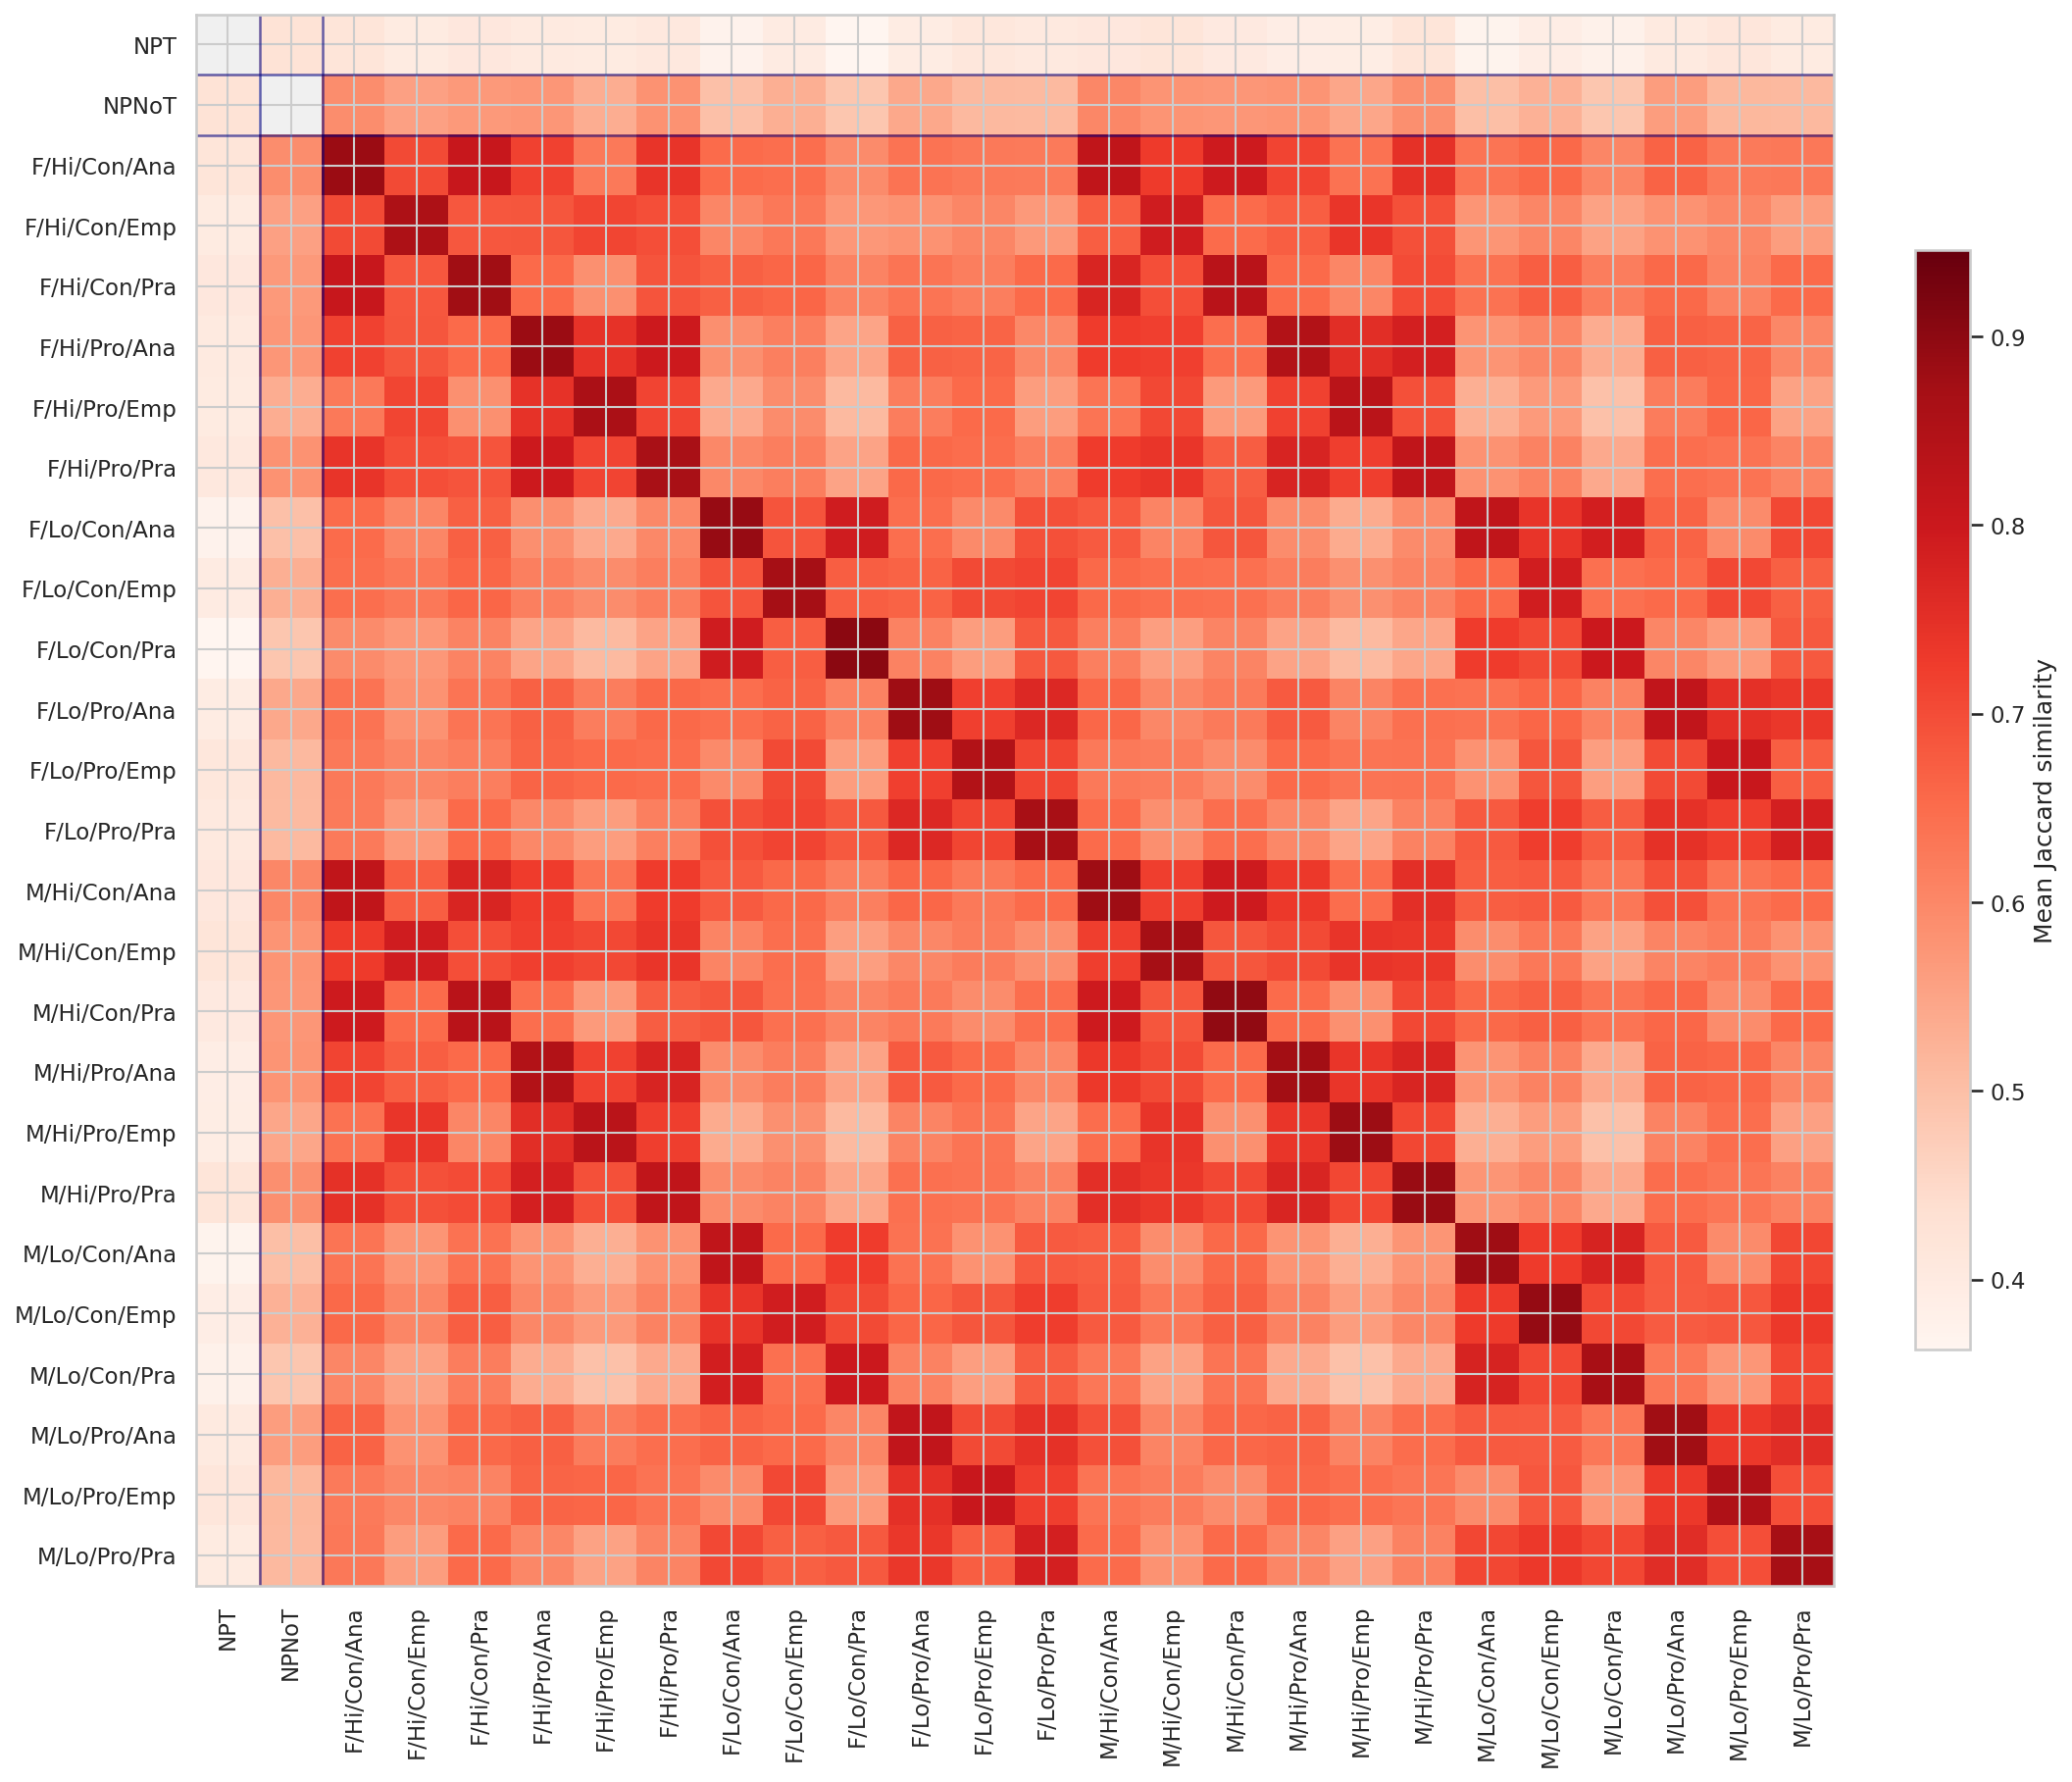

Saved fig_no_persona_full_sim_matrix_perception_jaccard


In [6]:
# Build (26, 26) cross-condition similarity matrices for captions, justifications, and perception tags.
# Conditions: [NPT, NPNoT, profile_0, ..., profile_23]
# Off-diagonal (i≠j): mean per-image similarity between condition i and j.
# Diagonal (i=i): mean within-condition pairwise similarity on the same image.

import ast as _ast

_labs_path = OUTPUTS / "profile_sim_labels.csv"
if _labs_path.exists():
    profile_labels = pd.read_csv(_labs_path)["profile"].tolist()
else:
    profile_labels = sorted(df["profile"].unique())
    pd.DataFrame({"profile": profile_labels}).to_csv(_labs_path, index=False)
n_profiles = len(profile_labels)
conditions_all = ["NPT", "NPNoT"] + profile_labels
n_cond = len(conditions_all)  # 26

# Sort np_think / np_nothink by image_id to get a stable order
img_ids = sorted(np_think_df["image_id"].unique())
n_img   = len(img_ids)
D_cap   = cap_embs.shape[1]
D_just  = just_embs.shape[1]

cap_all  = np.full((n_img, n_cond, D_cap),  np.nan, dtype=np.float32)
just_all = np.full((n_img, n_cond, D_just), np.nan, dtype=np.float32)
tag_all = [[None for _ in range(n_cond)] for _ in range(n_img)]
cap_diag_vals  = [[] for _ in range(n_cond)]
just_diag_vals = [[] for _ in range(n_cond)]
tag_diag_vals = [[] for _ in range(n_cond)]

def _tag_set(v):
    if isinstance(v, list):
        return set(v)
    try:
        return set(_ast.literal_eval(v))
    except Exception:
        return set()

def _jaccard(a, b):
    union = len(a | b)
    return len(a & b) / union if union > 0 else 0.0

npt_idx_map   = {row.image_id: i for i, row in np_think_df.iterrows()}
npnt_idx_map  = {row.image_id: i for i, row in np_nothink_df.iterrows()}
prof_map       = {p: i for i, p in enumerate(profile_labels)}

for img_i, img_id in enumerate(img_ids):
    if img_id in npt_idx_map:
        ri = npt_idx_map[img_id]
        cap_all[img_i, 0]  = np_think_cap_embs[ri]
        just_all[img_i, 0] = np_think_just_embs[ri]
        tag_all[img_i][0] = [_tag_set(np_think_df.loc[ri, "predicted_perceptions"])]
    if img_id in npnt_idx_map:
        ri = npnt_idx_map[img_id]
        cap_all[img_i, 1]  = np_nothink_cap_embs[ri]
        just_all[img_i, 1] = np_nothink_just_embs[ri]
        tag_all[img_i][1] = [_tag_set(np_nothink_df.loc[ri, "predicted_perceptions"])]
    img_anns = df[df["image_id"] == img_id]
    for prof, grp in img_anns.groupby("profile"):
        if prof not in prof_map:
            continue
        emb_idxs = [_ann2idx[a] for a in grp["annotation_id"].tolist() if a in _ann2idx]
        if not emb_idxs:
            continue
        pi = 2 + prof_map[prof]
        cap_group = cap_embs[emb_idxs]
        just_group = just_embs[emb_idxs]
        tag_sets = [_tag_set(v) for v in grp["predicted_perceptions"].tolist()]
        cap_all[img_i, pi] = cap_group.mean(axis=0)
        just_all[img_i, pi] = just_group.mean(axis=0)
        tag_all[img_i][pi] = tag_sets
        if len(emb_idxs) >= 2:
            tri = np.triu_indices(len(emb_idxs), k=1)
            cap_diag_vals[pi].append(float((cap_group @ cap_group.T)[tri].mean()))
            just_diag_vals[pi].append(float((just_group @ just_group.T)[tri].mean()))
        if len(tag_sets) >= 2:
            pairs = [_jaccard(a, b) for i, a in enumerate(tag_sets) for b in tag_sets[i + 1:]]
            if pairs:
                tag_diag_vals[pi].append(float(np.mean(pairs)))


def _build_sim_matrix(emb_all, diag_vals):
    """emb_all shape: (n_img, n_cond, D) with NaN for missing."""
    n_img, n_cond, D = emb_all.shape
    mat = np.full((n_cond, n_cond), np.nan)
    for ci in range(n_cond):
        for cj in range(n_cond):
            ei = emb_all[:, ci, :]  # (n_img, D)
            ej = emb_all[:, cj, :]
            if ci == cj:
                # Same convention as compute_image_conditioned_profile_sim:
                # mean within-condition pairwise cosine on the same image.
                mat[ci, cj] = float(np.mean(diag_vals[ci])) if diag_vals[ci] else np.nan
            else:
                valid = ~np.isnan(ei[:, 0]) & ~np.isnan(ej[:, 0])
                if valid.sum() == 0:
                    mat[ci, cj] = np.nan
                else:
                    sims = np.einsum("nd,nd->n", ei[valid], ej[valid])
                    mat[ci, cj] = sims.mean()
    return mat

cap_sim_mat  = _build_sim_matrix(cap_all, cap_diag_vals)
just_sim_mat = _build_sim_matrix(just_all, just_diag_vals)

def _build_jaccard_matrix(tag_all, diag_vals):
    mat = np.full((n_cond, n_cond), np.nan)
    for ci in range(n_cond):
        for cj in range(n_cond):
            if ci == cj:
                mat[ci, cj] = float(np.mean(diag_vals[ci])) if diag_vals[ci] else np.nan
                continue
            vals = []
            for img_tags in tag_all:
                si = img_tags[ci]
                sj = img_tags[cj]
                if not si or not sj:
                    continue
                pairs = [_jaccard(a, b) for a in si for b in sj]
                if pairs:
                    vals.append(float(np.mean(pairs)))
            mat[ci, cj] = float(np.mean(vals)) if vals else np.nan
    return mat

perc_sim_mat = _build_jaccard_matrix(tag_all, tag_diag_vals)

# Short display labels (truncate long profile strings)
def _short_label(s):
    if s in ("NPT", "NPNoT"):
        return s
    parts = [x.strip() for x in s.split("/")]
    gender = parts[0][0] if parts else "?"        # F / M
    econ   = "Hi" if "High" in s else "Lo"
    pol    = "Con" if "Con" in s else "Pro"
    pers   = parts[3][:3] if len(parts) > 3 else "?"
    return f"{gender}/{econ}/{pol}/{pers}"

short_labels = [_short_label(c) for c in conditions_all]

all_vals = np.concatenate([
    cap_sim_mat[~np.isnan(cap_sim_mat)],
    just_sim_mat[~np.isnan(just_sim_mat)],
    perc_sim_mat[~np.isnan(perc_sim_mat)],
])
shared_vmin, shared_vmax = float(all_vals.min()), float(all_vals.max())

def _save_matrix_fig(mat, cbar_label, fname):
    fig, ax = plt.subplots(figsize=(14, 12), constrained_layout=True)
    mask = np.isnan(mat)
    cmap = plt.get_cmap("Reds").copy()
    cmap.set_bad(color="#f0f0f0")
    im = ax.imshow(np.ma.masked_invalid(mat), aspect="auto", cmap=cmap,
                   vmin=shared_vmin, vmax=shared_vmax)
    ax.set_xticks(range(n_cond)); ax.set_xticklabels(short_labels, rotation=90, fontsize=11)
    ax.set_yticks(range(n_cond)); ax.set_yticklabels(short_labels, fontsize=11)
    # Highlight NPT and NPNoT rows/cols
    for k in range(2):
        ax.axhline(k + 0.5, color="navy", linewidth=1.2, alpha=0.6)
        ax.axvline(k + 0.5, color="navy", linewidth=1.2, alpha=0.6)
    cbar = plt.colorbar(im, ax=ax, shrink=0.7, label=cbar_label)
    cbar.ax.tick_params(labelsize=11)
    cbar.set_label(cbar_label, fontsize=12)
    fig.savefig(FIGURES / f"{fname}.pdf", bbox_inches="tight")
    fig.savefig(FIGURES / f"{fname}.png", bbox_inches="tight")
    plt.show()
    print(f"Saved {fname}")

_save_matrix_fig(cap_sim_mat, "Mean cosine similarity",
                 "fig_no_persona_full_sim_matrix_caption")
_save_matrix_fig(just_sim_mat, "Mean cosine similarity",
                 "fig_no_persona_full_sim_matrix_justification")
_save_matrix_fig(perc_sim_mat, "Mean Jaccard similarity",
                 "fig_no_persona_full_sim_matrix_perception_jaccard")
